# 03 - Classical Baselines

## Goal
Set honest non-neural baselines on the held-out test split before moving to LSTM/XGBoost tuning.

Models here:
- Naive last value
- Seasonal naive
- ARIMA
- Ridge
- Lasso

In [1]:
from pathlib import Path
import sys
import json
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.arima.model import ARIMA

ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.project_utils import ensure_project_dirs, seed_everything

seed_everything(42)
paths = ensure_project_dirs()
base_dir = paths["results"] / "baselines"
base_dir.mkdir(parents=True, exist_ok=True)

pd.options.display.max_columns = 200

print("Repo root:", ROOT)
print("Baselines dir:", base_dir)

Repo root: C:\Users\User\Downloads\261-Project
Baselines dir: C:\Users\User\Downloads\261-Project\results\baselines


## Config
- `N_LAGS` default: 60 months
- ARIMA order stays simple/fixed for transparency
- MASE uses in-sample history only (`train + val`)

In [2]:
N_LAGS = 60
SEASONAL_PERIOD = 12
MASE_M = 1
ARIMA_ORDER = (1, 0, 0)
RIDGE_ALPHA = 1.0
LASSO_ALPHA = 0.01

print("N_LAGS:", N_LAGS)
print("ARIMA_ORDER:", ARIMA_ORDER)

N_LAGS: 60
ARIMA_ORDER: (1, 0, 0)


## Load modeling table and split metadata
Inputs from notebook 02:
- `data/processed/modeling_table_full.csv`
- `data/processed/split_metadata.json`

If specific feature-set table is missing, notebook falls back to available table and filters to metadata features.

In [3]:
split_meta_path = paths["processed_data"] / "split_metadata.json"
if not split_meta_path.exists():
    raise FileNotFoundError("Missing split metadata. Run notebook 02 first.")
split_meta = json.loads(split_meta_path.read_text(encoding="utf-8"))

preferred_table = paths["processed_data"] / "modeling_table_full.csv"
if preferred_table.exists():
    model_path = preferred_table
else:
    candidates = sorted(paths["processed_data"].glob("modeling_table_*.csv"))
    if not candidates:
        raise FileNotFoundError("No modeling table found. Run notebook 02 first.")
    model_path = candidates[0]

model_df = pd.read_csv(model_path, index_col=0, parse_dates=True).sort_index()

TARGET_NAME = split_meta["target_name"]
if TARGET_NAME not in model_df.columns:
    raise KeyError(f"Target {TARGET_NAME} not found in modeling table")

selected_features = split_meta.get("selected_features", [c for c in model_df.columns if c != TARGET_NAME])
selected_features = [c for c in selected_features if c in model_df.columns and c != TARGET_NAME]

train_end = int(split_meta["boundaries"]["train_end_idx"])
val_end = int(split_meta["boundaries"]["val_end_idx"])

if not (0 < train_end < val_end < len(model_df)):
    raise ValueError("Invalid split boundaries from metadata")

X_df = model_df[selected_features].copy()
y_sr = model_df[TARGET_NAME].copy()

y_train = y_sr.iloc[:train_end]
y_val = y_sr.iloc[train_end:val_end]
y_test = y_sr.iloc[val_end:]
y_insample = y_sr.iloc[:val_end]  # used for MASE scale only

print("Model table:", model_path)
print("Rows:", len(model_df), "Features:", len(selected_features))
print("Target:", TARGET_NAME)
print("Split rows:", {"train": len(y_train), "val": len(y_val), "test": len(y_test)})

Model table: C:\Users\User\Downloads\261-Project\data\processed\modeling_table_full.csv
Rows: 395 Features: 22
Target: target_yoy_t_plus_1
Split rows: {'train': 276, 'val': 59, 'test': 60}


## Metrics
All reported metrics are on the true held-out test segment.

MASE details:
- denominator uses in-sample history only (`train + val`)
- no test information is used in scaling

In [4]:
def mae(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.mean(np.abs(y_true - y_pred)))


def smape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.abs(y_true) + np.abs(y_pred) + eps
    return float(100.0 * np.mean(2.0 * np.abs(y_pred - y_true) / denom))


def mase(y_true, y_pred, y_insample, m=1, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_insample = np.asarray(y_insample)
    if len(y_insample) <= m:
        return float("nan")
    scale = np.mean(np.abs(y_insample[m:] - y_insample[:-m]))
    return float(np.mean(np.abs(y_true - y_pred)) / (scale + eps))


def evaluate_model(name, y_true, y_pred, y_insample, mase_m=1):
    return {
        "model": name,
        "mae": mae(y_true, y_pred),
        "smape": smape(y_true, y_pred),
        "mase": mase(y_true, y_pred, y_insample, m=mase_m),
    }


print("MASE scale history length (train+val only):", len(y_insample))

MASE scale history length (train+val only): 335


## Time-series baselines
- **Naive last**: previous observed target
- **Seasonal naive**: value from 12 months ago
- **ARIMA**: trained on in-sample target history only

In [5]:
# Naive baselines from target history
y_naive_last = y_sr.shift(1).loc[y_test.index]
y_naive_seasonal = y_sr.shift(SEASONAL_PERIOD).loc[y_test.index]

# ARIMA baseline fitted only on in-sample history
arima_model = ARIMA(y_insample, order=ARIMA_ORDER)
arima_fit = arima_model.fit()
y_arima = pd.Series(arima_fit.forecast(steps=len(y_test)), index=y_test.index)

# keep aligned non-null segments (seasonal naive may drop earliest test points)
def aligned_eval(y_true_sr, y_pred_sr):
    joint = pd.concat([y_true_sr.rename("y"), y_pred_sr.rename("p")], axis=1).dropna()
    return joint["y"], joint["p"]

y_t_last, y_p_last = aligned_eval(y_test, y_naive_last)
y_t_seas, y_p_seas = aligned_eval(y_test, y_naive_seasonal)
y_t_arima, y_p_arima = aligned_eval(y_test, y_arima)

metrics_ts = []
metrics_ts.append(evaluate_model("NaiveLast", y_t_last, y_p_last, y_insample, mase_m=MASE_M))
metrics_ts.append(evaluate_model("SeasonalNaive", y_t_seas, y_p_seas, y_insample, mase_m=MASE_M))
metrics_ts.append(evaluate_model("ARIMA(1,0,0)", y_t_arima, y_p_arima, y_insample, mase_m=MASE_M))

pd.DataFrame(metrics_ts).sort_values("mae")

C:\Users\User\Downloads\261-Project\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\User\Downloads\261-Project\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\User\Downloads\261-Project\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


,model,mae,smape,mase
0,NaiveLast,0.340550,8.481803,1.250964
1,SeasonalNaive,2.543939,58.714027,9.344813
2,"ARIMA(1,0,0)",2.553635,64.992298,9.380430


## Ridge/Lasso with two lag-window representations
From the same lag window:
1. `mean_pooled`: average each feature over the window
2. `flattened`: concatenate lagged features in time order

We compare both and keep the better one by validation MAE.

In [6]:
def build_tabular_windows(X_df, y_sr, n_lags=60, representation="mean_pooled"):
    X_values = X_df.values
    y_values = y_sr.values
    idx = X_df.index

    X_out, y_out, idx_out = [], [], []
    for i in range(n_lags, len(X_df)):
        block = X_values[i - n_lags : i, :]
        if representation == "mean_pooled":
            feat = block.mean(axis=0)
        elif representation == "flattened":
            feat = block.reshape(-1)
        else:
            raise ValueError("representation must be mean_pooled or flattened")
        X_out.append(feat)
        y_out.append(y_values[i])
        idx_out.append(idx[i])

    return np.asarray(X_out), np.asarray(y_out), pd.Index(idx_out)


def split_by_index_boundary(X_all, y_all, idx_all, train_end_idx, val_end_idx):
    train_mask = idx_all < y_sr.index[train_end_idx]
    val_mask = (idx_all >= y_sr.index[train_end_idx]) & (idx_all < y_sr.index[val_end_idx])
    test_mask = idx_all >= y_sr.index[val_end_idx]

    return (
        X_all[train_mask], y_all[train_mask],
        X_all[val_mask], y_all[val_mask],
        X_all[test_mask], y_all[test_mask], idx_all[test_mask]
    )


ridge_alpha_grid = [1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100, 1000]
lasso_alpha_grid = [1e-4, 1e-3, 1e-2, 1e-1, 1, 10]

rep_results = []
final_linear_metrics = []
pred_store = {}

for model_name in ["Ridge", "Lasso"]:
    val_scores = {}
    rep_test_cache = {}
    chosen_alpha = {}

    for rep in ["mean_pooled", "flattened"]:
        X_all, y_all, idx_all = build_tabular_windows(X_df, y_sr, n_lags=N_LAGS, representation=rep)
        X_tr, y_tr, X_va, y_va, X_te, y_te, idx_te = split_by_index_boundary(X_all, y_all, idx_all, train_end, val_end)

        scaler = StandardScaler()
        X_tr_sc = scaler.fit_transform(X_tr)
        X_va_sc = scaler.transform(X_va)

        if model_name == "Ridge":
            grid = ridge_alpha_grid
            make_model = lambda a: Ridge(alpha=a)
        else:
            grid = lasso_alpha_grid
            make_model = lambda a: Lasso(alpha=a, max_iter=30000, random_state=42)

        best_alpha = None
        best_val = float("inf")
        for alpha in grid:
            mdl = make_model(alpha)
            mdl.fit(X_tr_sc, y_tr)
            y_va_pred_raw = mdl.predict(X_va_sc)
            # Stability guardrail for linear extrapolation in regime-shift periods.
            y_va_pred = np.clip(y_va_pred_raw, y_tr.min(), y_tr.max())
            v = mae(y_va, y_va_pred)
            if v < best_val:
                best_val = float(v)
                best_alpha = alpha

        val_scores[rep] = best_val
        chosen_alpha[rep] = best_alpha

        rep_results.append({
            "model_family": model_name,
            "representation": rep,
            "val_mae": float(best_val),
            "best_alpha": float(best_alpha),
            "n_features_after_rep": int(X_tr.shape[1]),
            "n_train_windows": int(len(y_tr)),
            "n_val_windows": int(len(y_va)),
            "n_test_windows": int(len(y_te)),
        })

        rep_test_cache[rep] = (X_all, y_all, idx_all)

    best_rep = min(val_scores, key=val_scores.get)

    # Refit on train+val with selected representation and tuned alpha, evaluate on held-out test.
    X_all, y_all, idx_all = rep_test_cache[best_rep]
    trainval_mask = idx_all < y_sr.index[val_end]
    test_mask = idx_all >= y_sr.index[val_end]

    X_trainval = X_all[trainval_mask]
    y_trainval = y_all[trainval_mask]
    X_test_rep = X_all[test_mask]
    y_test_rep = y_all[test_mask]
    idx_test_rep = idx_all[test_mask]

    scaler = StandardScaler()
    X_trainval_sc = scaler.fit_transform(X_trainval)
    X_test_rep_sc = scaler.transform(X_test_rep)

    alpha = chosen_alpha[best_rep]
    if model_name == "Ridge":
        best_model = Ridge(alpha=alpha)
    else:
        best_model = Lasso(alpha=alpha, max_iter=30000, random_state=42)

    best_model.fit(X_trainval_sc, y_trainval)
    y_pred_test_raw = best_model.predict(X_test_rep_sc)
    # Use train+val target range as an outlier guardrail for linear baselines.
    y_pred_test_rep = np.clip(y_pred_test_raw, y_trainval.min(), y_trainval.max())

    eval_row = evaluate_model(
        f"{model_name}[{best_rep}]",
        y_test_rep,
        y_pred_test_rep,
        y_insample,
        mase_m=MASE_M,
    )
    eval_row["chosen_representation"] = best_rep
    eval_row["val_mae_best_rep"] = float(val_scores[best_rep])
    eval_row["best_alpha"] = float(alpha)
    eval_row["prediction_clipping"] = "trainval_target_range"

    final_linear_metrics.append(eval_row)
    pred_store[eval_row["model"]] = pd.Series(y_pred_test_rep, index=idx_test_rep)

rep_cmp_df = pd.DataFrame(rep_results).sort_values(["model_family", "val_mae"])
rep_cmp_df


,model_family,representation,val_mae,best_alpha,n_features_after_rep,n_train_windows,n_val_windows,n_test_windows
3,Lasso,flattened,0.291213,0.1,1320,216,59,60
2,Lasso,mean_pooled,0.581322,1.0,22,216,59,60
1,Ridge,flattened,0.732008,1000.0,1320,216,59,60
0,Ridge,mean_pooled,0.800301,1000.0,22,216,59,60


### Representation takeaway
Validation MAE decides the better linear representation.

In this dataset, flattened windows can help because they preserve timing details, while mean pooling is simpler and often more stable when data is noisy.

In [7]:
# Combine final held-out test metrics
all_metrics = metrics_ts + final_linear_metrics
baseline_df = pd.DataFrame(all_metrics).sort_values("mae").reset_index(drop=True)

# Save JSON and markdown table
json_path = base_dir / "baseline_metrics.json"
md_path = base_dir / "baseline_table.md"
rep_md_path = base_dir / "representation_comparison.md"

payload = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "target_name": TARGET_NAME,
    "n_lags": N_LAGS,
    "test_start": str(y_test.index.min().date()),
    "test_end": str(y_test.index.max().date()),
    "mase_scale_history": "train+val only",
    "metrics": baseline_df.to_dict(orient="records"),
    "representation_validation": rep_cmp_df.to_dict(orient="records"),
}
json_path.write_text(json.dumps(payload, indent=2), encoding="utf-8")


def df_to_markdown_robust(df: pd.DataFrame) -> str:
    try:
        return df.to_markdown(index=False, floatfmt=".4f")
    except Exception:
        # fallback: plain markdown builder without optional dependencies
        out = df.copy()
        for col in out.columns:
            if pd.api.types.is_float_dtype(out[col]):
                out[col] = out[col].map(lambda v: f"{v:.4f}")
            else:
                out[col] = out[col].astype(str)

        headers = list(out.columns)
        lines = []
        lines.append("| " + " | ".join(headers) + " |")
        lines.append("| " + " | ".join(["---"] * len(headers)) + " |")
        for _, row in out.iterrows():
            lines.append("| " + " | ".join(row.tolist()) + " |")
        return "\n".join(lines)


md_table = df_to_markdown_robust(baseline_df)
md_path.write_text(md_table + "\n", encoding="utf-8")

rep_md = df_to_markdown_robust(rep_cmp_df)
rep_md_path.write_text(rep_md + "\n", encoding="utf-8")

print("Saved:", json_path)
print("Saved:", md_path)
print("Saved:", rep_md_path)
baseline_df


Saved: C:\Users\User\Downloads\261-Project\results\baselines\baseline_metrics.json
Saved: C:\Users\User\Downloads\261-Project\results\baselines\baseline_table.md
Saved: C:\Users\User\Downloads\261-Project\results\baselines\representation_comparison.md


,model,mae,smape,mase,chosen_representation,val_mae_best_rep,best_alpha,prediction_clipping
0,NaiveLast,0.340550,8.481803,1.250964,NaN,NaN,NaN,NaN
1,Lasso[flattened],1.044402,21.990918,3.836468,flattened,0.291213,0.1,trainval_target_range
2,SeasonalNaive,2.543939,58.714027,9.344813,NaN,NaN,NaN,NaN
3,"ARIMA(1,0,0)",2.553635,64.992298,9.380430,NaN,NaN,NaN,NaN
4,Ridge[flattened],3.991319,115.498733,14.661564,flattened,0.732008,1000.0,trainval_target_range


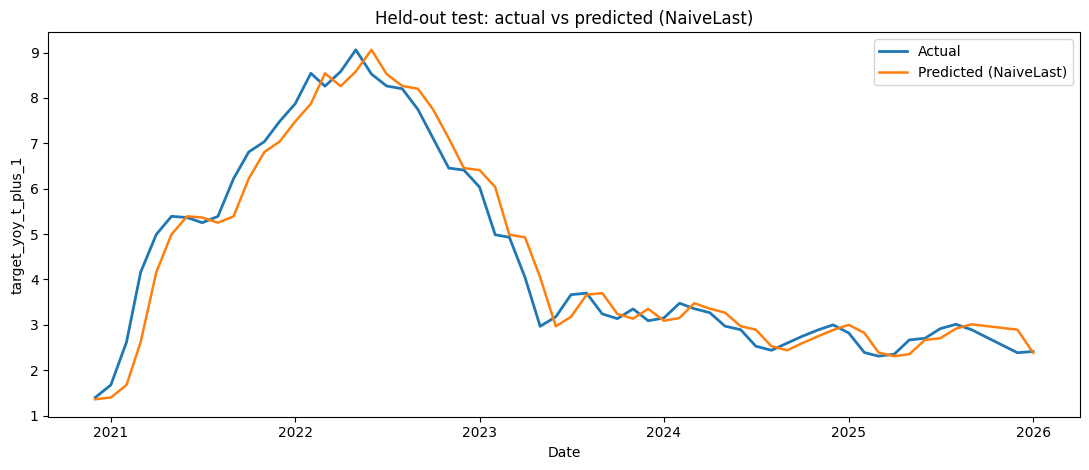

Saved: C:\Users\User\Downloads\261-Project\results\baselines\best_baseline_actual_vs_pred.png


In [8]:
# Plot strongest baseline (lowest test MAE)
best_model_name = baseline_df.iloc[0]["model"]

if best_model_name == "NaiveLast":
    y_pred_best = y_naive_last
elif best_model_name == "SeasonalNaive":
    y_pred_best = y_naive_seasonal
elif best_model_name.startswith("ARIMA"):
    y_pred_best = y_arima
else:
    y_pred_best = pred_store[best_model_name]

plot_df = pd.concat([
    y_test.rename("actual"),
    pd.Series(y_pred_best, name="pred")
], axis=1).dropna()

plt.figure(figsize=(11, 4.8))
plt.plot(plot_df.index, plot_df["actual"], label="Actual", linewidth=2)
plt.plot(plot_df.index, plot_df["pred"], label=f"Predicted ({best_model_name})", linewidth=1.8)
plt.title(f"Held-out test: actual vs predicted ({best_model_name})")
plt.xlabel("Date")
plt.ylabel(TARGET_NAME)
plt.legend()
plt.tight_layout()

plot_path = base_dir / "best_baseline_actual_vs_pred.png"
plt.savefig(plot_path, dpi=150)
plt.show()
print("Saved:", plot_path)

## Verification checks
- final metrics come from held-out test dates only
- MASE scaling uses in-sample history only (`train + val`)

In [9]:
# Verify true held-out test evaluation for final baseline table
final_models = set(baseline_df["model"])
print("Final models:", final_models)
print("Test period:", y_test.index.min().date(), "to", y_test.index.max().date(), "| n=", len(y_test))
print("MASE scale history length:", len(y_insample), "(train+val)")

assert len(y_insample) == val_end, "MASE in-sample history should be pre-test only"
assert len(y_test) == (len(y_sr) - val_end), "Test segment mismatch"
assert all(col in baseline_df.columns for col in ["mae", "smape", "mase"]), "Missing metric columns"

print("Held-out test evaluation check: PASS")
print("MASE in-sample scaling check: PASS")

Final models: {'Ridge[flattened]', 'NaiveLast', 'SeasonalNaive', 'Lasso[flattened]', 'ARIMA(1,0,0)'}
Test period: 2020-12-01 to 2026-01-01 | n= 60
MASE scale history length: 335 (train+val)
Held-out test evaluation check: PASS
MASE in-sample scaling check: PASS
